<a href="https://colab.research.google.com/github/ljbpavan78/Curso-IA-Fatec-Rio-Claro/blob/main/Redes_Neurais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import metrics
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from google.colab import drive

In [17]:
drive.mount('/content/drive')
df=pd.read_csv('/content/drive/MyDrive/IntroAI/irisMLP.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
print(df.head())

   sepal.length  sepal.width  petal.length  petal.width      variety
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


In [19]:
y= df.iloc[0:100, 4].values
print(y)

['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor

In [20]:
y=np.where(y=='Iris-setosa', -1, 1)
print(y)

[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1]


In [21]:
x=df.iloc[0:100,[0,1,2,3]].values
print(x)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [22]:
scaler=preprocessing.MinMaxScaler()
x=scaler.fit_transform(x)
print(x)

[[0.2962963  0.625      0.09756098 0.05882353]
 [0.22222222 0.41666667 0.09756098 0.05882353]
 [0.14814815 0.5        0.07317073 0.05882353]
 [0.11111111 0.45833333 0.12195122 0.05882353]
 [0.25925926 0.66666667 0.09756098 0.05882353]
 [0.40740741 0.79166667 0.17073171 0.17647059]
 [0.11111111 0.58333333 0.09756098 0.11764706]
 [0.25925926 0.58333333 0.12195122 0.05882353]
 [0.03703704 0.375      0.09756098 0.05882353]
 [0.22222222 0.45833333 0.12195122 0.        ]
 [0.40740741 0.70833333 0.12195122 0.05882353]
 [0.18518519 0.58333333 0.14634146 0.05882353]
 [0.18518519 0.41666667 0.09756098 0.        ]
 [0.         0.41666667 0.02439024 0.        ]
 [0.55555556 0.83333333 0.04878049 0.05882353]
 [0.51851852 1.         0.12195122 0.17647059]
 [0.40740741 0.79166667 0.07317073 0.17647059]
 [0.2962963  0.625      0.09756098 0.11764706]
 [0.51851852 0.75       0.17073171 0.11764706]
 [0.2962963  0.75       0.12195122 0.11764706]
 [0.40740741 0.58333333 0.17073171 0.05882353]
 [0.2962963  

[]

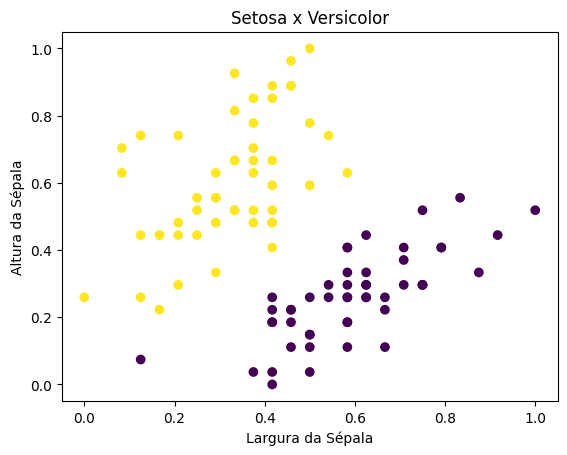

In [23]:
plt.scatter(x[:,1],x[:,0], c=y)
plt.title("Setosa x Versicolor")
plt.xlabel("Largura da Sépala")
plt.ylabel("Altura da Sépala")
plt.plot()


In [25]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.3)

In [26]:
x_train.shape

(70, 4)

In [27]:
p=Perceptron(random_state=42, eta0=0.0001, alpha=0.1)

In [28]:
p.fit(x_train, y_train)

Perceptron(alpha=0.1, eta0=0.0001, random_state=42)

In [29]:
predictions_train=p.predict(x_train)

In [30]:
train_score=accuracy_score(y_train, predictions_train)
print("A acurácia dos dados de treinamento é ", train_score)

A acurácia dos dados de treinamento é  1.0


In [31]:
predictions_test=p.predict(x_test)

In [35]:
test_score=accuracy_score(y_test, predictions_test)
print("A acurácia com dados de teste ", test_score)

A acurácia com dados de teste  1.0


In [36]:
print("Número de épocas de treinamento ", p.n_iter_)

Número de épocas de treinamento  6
